In [1]:
import pandas as pd
import numpy as np

In [2]:
import pandas as pd

# Load predictions from each model
logistic_results = pd.read_csv(
    "../data/processed/logistic_predictions.csv"
)

random_forest_results = pd.read_csv(
    "../data/processed/random_forest_predictions.csv"
)

xgboost_results = pd.read_csv(
    "../data/processed/xgboost_predictions.csv"
)

# Display the first 5 rows
logistic_results.head()

,Actual_Churn,Predicted_Churn,Churn_Probability
0,0,0,0.108341
1,0,1,0.841004
2,0,0,0.106800
3,0,1,0.630826
4,0,0,0.055787


In [3]:
print("Logistic Regression:", logistic_results.shape)
print("Random Forest:", random_forest_results.shape)
print("XGBoost:", xgboost_results.shape)

Logistic Regression: (1409, 3)
Random Forest: (1409, 3)
XGBoost: (1409, 3)


In [4]:
# Check whether actual churn values are identical
print(
    "Logistic vs Random Forest:",
    logistic_results["Actual_Churn"].equals(
        random_forest_results["Actual_Churn"]
    )
)

print(
    "Logistic vs XGBoost:",
    logistic_results["Actual_Churn"].equals(
        xgboost_results["Actual_Churn"]
    )
)

Logistic vs Random Forest: True
Logistic vs XGBoost: True


In [5]:
# Create a comparison table using saved results

comparison_data = {
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        (logistic_results["Actual_Churn"] ==
         logistic_results["Predicted_Churn"]).mean(),

        (random_forest_results["Actual_Churn"] ==
         random_forest_results["Predicted_Churn"]).mean(),

        (xgboost_results["Actual_Churn"] ==
         xgboost_results["Predicted_Churn"]).mean()
    ]
}

comparison_df = pd.DataFrame(comparison_data)

comparison_df

,Model,Accuracy
0,Logistic Regression,0.737402
1,Random Forest,0.775018
2,XGBoost,0.777147


In [6]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [7]:
# Function to calculate evaluation metrics

def evaluate_model(results):
    y_true = results["Actual_Churn"]
    y_pred = results["Predicted_Churn"]
    y_proba = results["Churn_Probability"]

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba)
    }

In [8]:
# Evaluate all three models

logistic_metrics = evaluate_model(logistic_results)
rf_metrics = evaluate_model(random_forest_results)
xgb_metrics = evaluate_model(xgboost_results)

# Create comparison table
comparison_df = pd.DataFrame([
    {"Model": "Logistic Regression", **logistic_metrics},
    {"Model": "Random Forest", **rf_metrics},
    {"Model": "XGBoost", **xgb_metrics}
])

# Display rounded values
comparison_df.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7374,0.5034,0.7941,0.6162,0.8402
1,Random Forest,0.7750,0.5807,0.5481,0.5640,0.8187
2,XGBoost,0.7771,0.5711,0.6444,0.6055,0.8418


In [9]:
# Save model comparison results

comparison_df.to_csv(
    "../reports/model_comparison.csv",
    index=False
)

print("Comparison table saved successfully!")

Comparison table saved successfully!


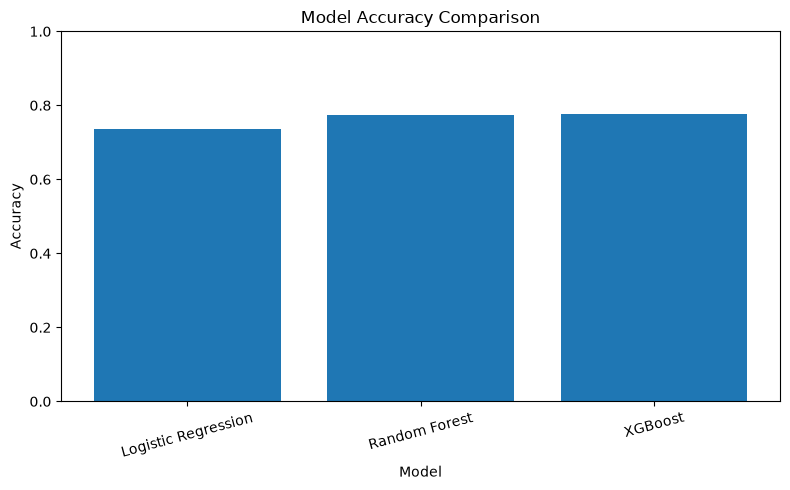

In [10]:
import matplotlib.pyplot as plt

# Plot model accuracy
plt.figure(figsize=(8, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()

plt.show()

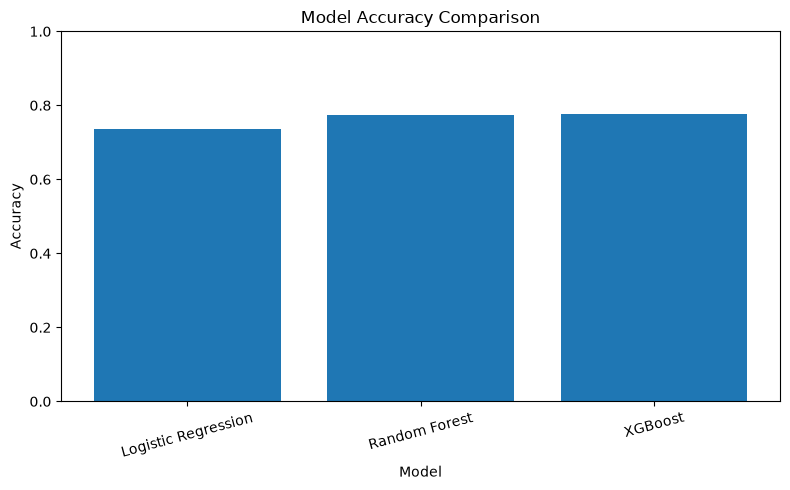

Chart saved successfully!


In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()

# Save the chart
plt.savefig(
    "../reports/figures/model_accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully!")

In [12]:
# Load the original dataset

raw_data = pd.read_csv(
    "../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

# Convert TotalCharges to numeric
raw_data["TotalCharges"] = pd.to_numeric(
    raw_data["TotalCharges"],
    errors="coerce"
)

# Fill missing TotalCharges values
raw_data["TotalCharges"] = raw_data["TotalCharges"].fillna(0)

# Convert churn labels into numbers
raw_data["Churn"] = raw_data["Churn"].map({
    "No": 0,
    "Yes": 1
})

raw_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [13]:
from sklearn.model_selection import train_test_split

# Separate features and target
X_raw = raw_data.drop(columns=["Churn"])
y_raw = raw_data["Churn"]

# Create the same train-test split
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw,
    y_raw,
    test_size=0.2,
    random_state=42,
    stratify=y_raw
)

print("Test data shape:", X_test_raw.shape)
print("Test labels shape:", y_test_raw.shape)

Test data shape: (1409, 20)
Test labels shape: (1409,)


In [14]:
# Rule-based churn risk baseline

rule_predictions = (
    (X_test_raw["Contract"] == "Month-to-month") &
    (X_test_raw["tenure"] < 12)
).astype(int)

# Check the results
print("High-risk customers flagged:", rule_predictions.sum())
print("Total test customers:", len(rule_predictions))

High-risk customers flagged: 384
Total test customers: 1409


In [15]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Actual churn values for the test set
rule_y_true = y_test_raw

# Rule predictions
rule_y_pred = rule_predictions

# Calculate metrics
rule_metrics = {
    "Accuracy": accuracy_score(rule_y_true, rule_y_pred),
    "Precision": precision_score(rule_y_true, rule_y_pred),
    "Recall": recall_score(rule_y_true, rule_y_pred),
    "F1-Score": f1_score(rule_y_true, rule_y_pred),
    "ROC-AUC": roc_auc_score(rule_y_true, rule_y_pred)
}

# Display results
pd.DataFrame([rule_metrics]).round(4)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,0.753,0.5339,0.5481,0.5409,0.6876


In [16]:
# Add rule-based baseline to the comparison table

rule_comparison_row = {
    "Model": "Rule-Based Baseline",
    **rule_metrics
}

comparison_df = pd.concat(
    [
        comparison_df,
        pd.DataFrame([rule_comparison_row])
    ],
    ignore_index=True
)

# Display complete comparison
comparison_df.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7374,0.5034,0.7941,0.6162,0.8402
1,Random Forest,0.7750,0.5807,0.5481,0.5640,0.8187
2,XGBoost,0.7771,0.5711,0.6444,0.6055,0.8418
3,Rule-Based Baseline,0.7530,0.5339,0.5481,0.5409,0.6876


In [17]:
# Save the complete comparison table

comparison_df.to_csv(
    "../reports/model_comparison.csv",
    index=False
)

print("Updated comparison table saved successfully!")

Updated comparison table saved successfully!


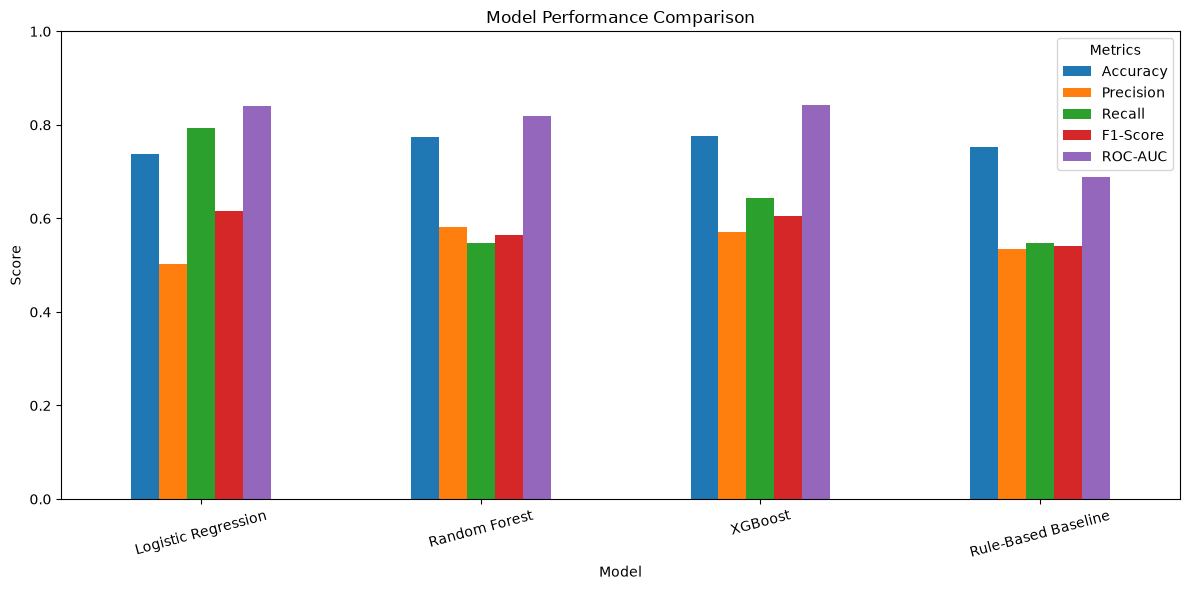

Complete comparison chart saved successfully!


In [18]:
import matplotlib.pyplot as plt

# Remove the Model column for plotting
metrics_df = comparison_df.set_index("Model")

# Create grouped bar chart
metrics_df.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=15)
plt.legend(title="Metrics")
plt.tight_layout()

# Save the chart
plt.savefig(
    "../reports/figures/model_performance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Complete comparison chart saved successfully!")

In [19]:
import os

files_to_check = [
    "../reports/model_comparison.csv",
    "../reports/figures/model_accuracy_comparison.png",
    "../reports/figures/model_performance_comparison.png"
]

for file in files_to_check:
    print(file, "->", os.path.exists(file))

../reports/model_comparison.csv -> True
../reports/figures/model_accuracy_comparison.png -> True
../reports/figures/model_performance_comparison.png -> True
